# plotting with a series

`.plot` has attribute `.hist()` and `.line`

In [ ]:
import pandas as pd
url = 'https://github.com/mattharrison/datasets/raw/master/'\
    'data/alta-noaa-1980-2019.csv'
alta_df = pd.read_csv(url)



In [2]:
alta_df.columns

Index(['STATION', 'NAME', 'LATITUDE', 'LONGITUDE', 'ELEVATION', 'DATE', 'DAPR',
       'DASF', 'MDPR', 'MDSF', 'PRCP', 'SNOW', 'SNWD', 'TMAX', 'TMIN', 'TOBS',
       'WT01', 'WT03', 'WT04', 'WT05', 'WT06', 'WT11'],
      dtype='object')

<Axes: title={'center': 'snow falls'}, ylabel='Frequency'>

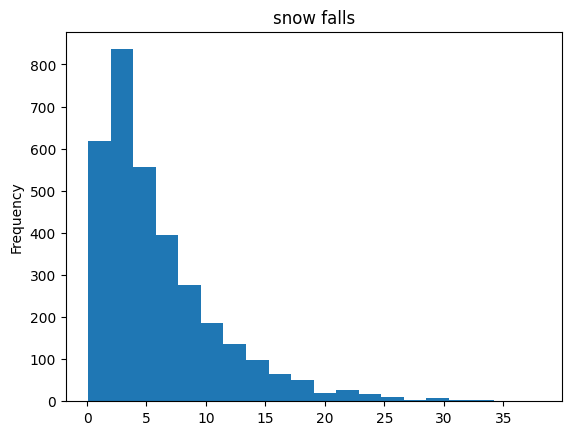

In [ ]:
dates=pd.to_datetime(alta_df['DATE'])
snow=alta_df['SNOW'].rename(dates) # return a series
snow[snow>0].plot.hist(bins=20, title='snow falls')

In [4]:
snow.index

DatetimeIndex(['1980-01-01', '1980-01-02', '1980-01-03', '1980-01-04',
               '1980-01-05', '1980-01-06', '1980-01-07', '1980-01-08',
               '1980-01-09', '1980-01-10',
               ...
               '2019-08-29', '2019-08-30', '2019-08-31', '2019-09-01',
               '2019-09-02', '2019-09-03', '2019-09-04', '2019-09-05',
               '2019-09-06', '2019-09-07'],
              dtype='datetime64[ns]', length=14160, freq=None)

<Axes: >

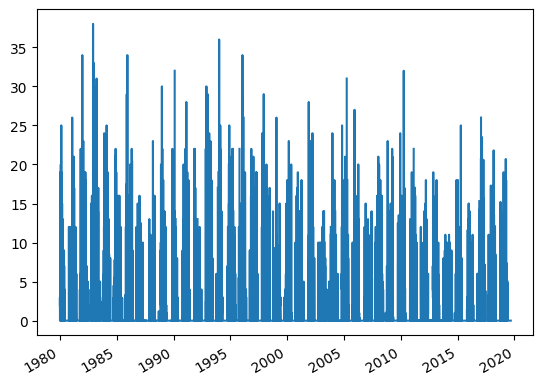

In [5]:
snow.plot.line()

<Axes: >

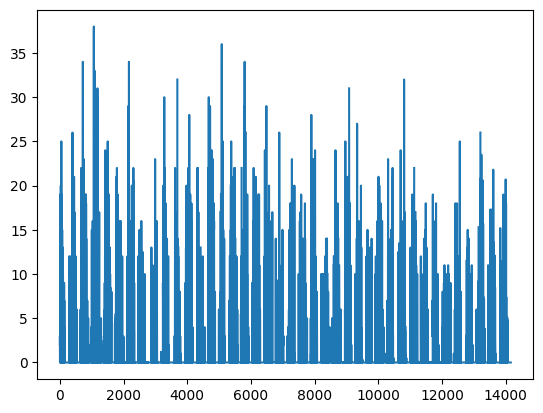

In [ ]:
alta_df['SNOW'].plot.line() # the index is not properly set

<Axes: >

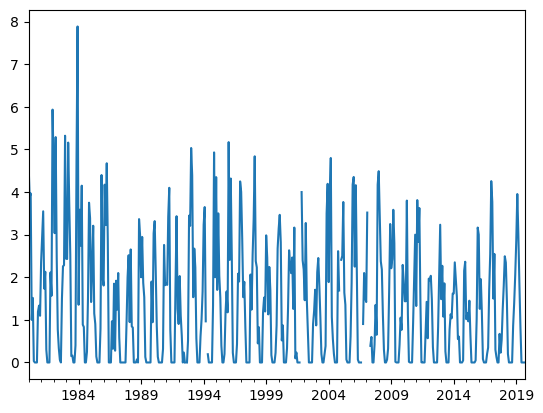

In [ ]:
# aggregate at the month end
# resample('ME'): grouping by the month end
snow.resample('ME').mean().plot.line()

<Axes: >

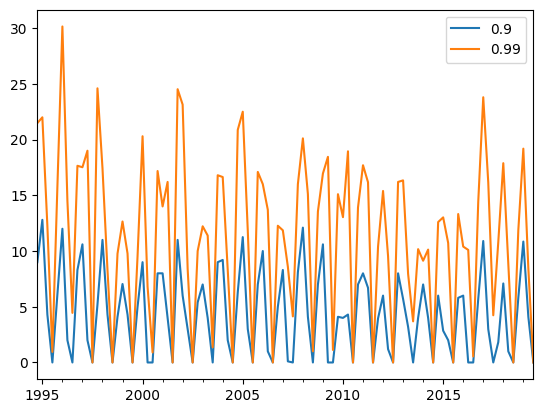

In [12]:
snow.resample('QE').quantile([.9,.99]).unstack().tail(100).plot.line()

<Axes: title={'center': '2017 Monthly Percent of Snowfall'}>

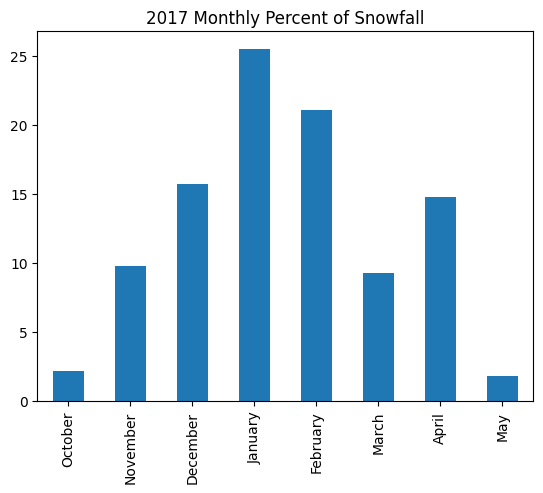

In [13]:
season2017 = snow.loc['2016-10':'2017-05']
season2017.resample('ME').sum().div(season2017.sum()).mul(100)\
    .rename(lambda idx: idx.month_name())\
    .plot.bar(title='2017 Monthly Percent of Snowfall')

# plotting with dataframe

<Axes: xlabel='PRCP', ylabel='SNOW'>

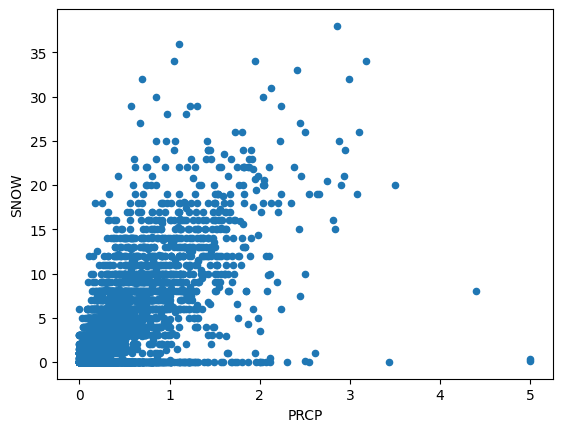

In [17]:
alta_df.plot.scatter(x='PRCP', y='SNOW')

<Axes: >

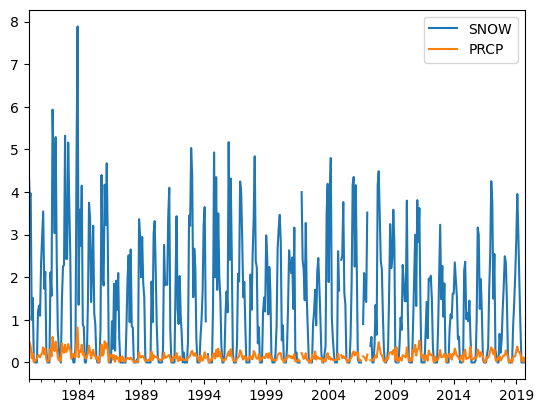

In [28]:
alta_df[['SNOW', 'PRCP']].rename(dates).resample('ME').mean().plot()


<Axes: xlabel='DATE'>

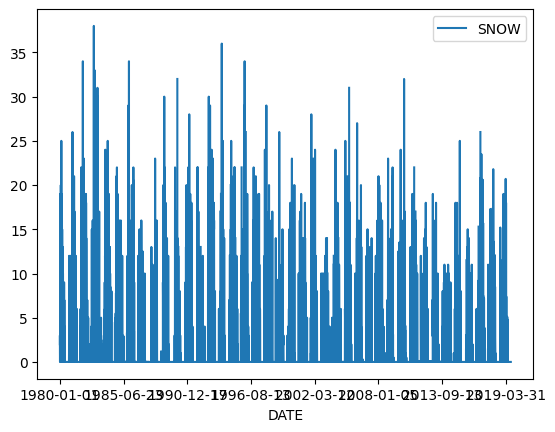

In [32]:
alta_df[['DATE','SNOW', 'PRCP']].plot(x='DATE', y='SNOW')
